In [88]:
import pandas as pd
import matplotlib.pyplot as plt

In [89]:
import keras
import numpy as np
from tensorflow.keras import layers, models
from keras.datasets import mnist
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D,UpSampling2D, Dropout
from keras.models import Sequential

In [90]:
(X_train,_),(X_test,_) = keras.datasets.mnist.load_data(path="mnist.npz")

In [91]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [92]:
X_train.reshape(-1,28,28,1).shape, X_test.reshape(-1,28,28,1).shape

((60000, 28, 28, 1), (10000, 28, 28, 1))

In [93]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

In [94]:
X_Train= X_train/255.0
X_Test= X_test/255.0

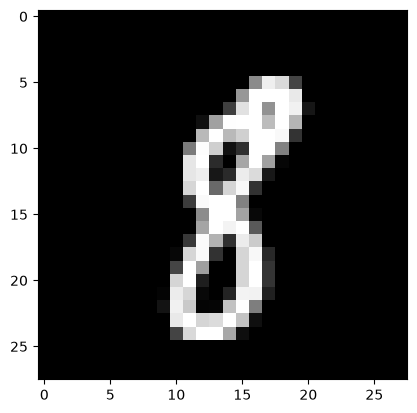

In [95]:
plt.imshow(X_Train[300], cmap='gray')

In [96]:
X_train_noise = X_Train + 0.2 * np.random.normal(loc=0.0, scale=1, size=X_train.shape)
X_test_noise =  X_Test + 0.2 * np.random.normal(loc=0.0, scale=1, size=X_test.shape)

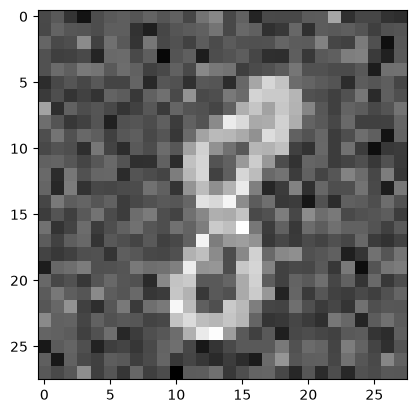

In [97]:
plt.imshow(X_train_noise[300], cmap='gray')

In [98]:
X_train_clipped = np.clip(X_train_noise, 0, 1)
X_test_clipped = np.clip(X_test_noise, 0, 1)

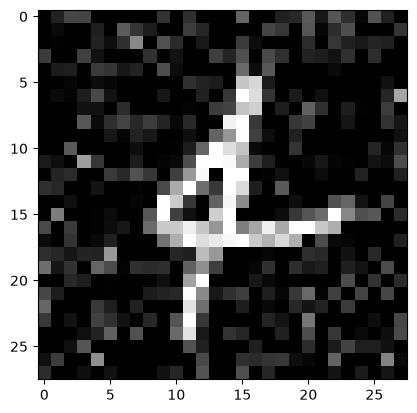

In [99]:
plt.imshow(X_test_clipped[300], cmap='gray')

In [106]:
model = Sequential()

# Encoder
model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))         

# Decoder
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))

model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(1, (3, 3), activation='sigmoid', padding='same'))

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_7 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
model.compile(optimizer='adam', loss='mean_squared_error',metrics=['accuracy'])

In [108]:
model.fit(
    x=X_train_clipped,
    y=X_Train,
    batch_size=32,
    epochs=5,
    validation_data=(X_test_clipped, X_Test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 16ms/step - accuracy: 0.8087 - loss: 0.1125 - val_accuracy: 0.8072 - val_loss: 0.1140
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8088 - loss: 0.1120 - val_accuracy: 0.8072 - val_loss: 0.1140
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.8088 - loss: 0.1120 - val_accuracy: 0.8072 - val_loss: 0.1140
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.8088 - loss: 0.1120 - val_accuracy: 0.8072 - val_loss: 0.1140
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8088 - loss: 0.1120 - val_accuracy: 0.8072 - val_loss: 0.1140


In [ ]:
model.evaluate(X_test_clipped, X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7956 - loss: 367.5062


[367.5062255859375, 0.7956051826477051]

In [ ]:
y_pred = model.predict(X_test_clipped)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


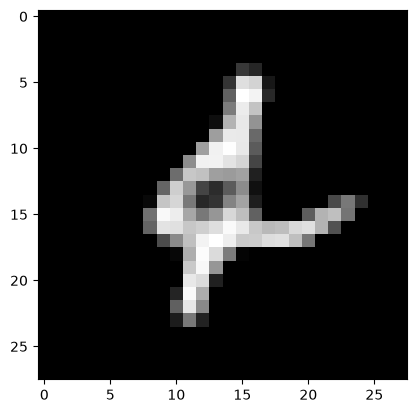

In [ ]:
plt.imshow(y_pred[300], cmap='gray')

In [ ]:
model.save('autoencoder_model.h5')